Tugas Pratikum

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_Kerja = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Pratikum1"
os.makedirs(DIR_Kerja, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'distribusi_per_jam.png', 'pengukuran_kinerja.csv']


In [3]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur (label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter()
    delta = rss_mb() -m0
    catatan.append({"Langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

Mengunduh dataset baru. Taksi Kuning Bulan Oktober

In [4]:
import urllib.request

URL =("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-10.parquet")
PATH_Baru = os.path.join(DIR_Kerja, "yellow_tripdata_2023-10.parquet")

if not os.path.exists (PATH_Baru):
  ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH_Baru))

  print("Ukuran fille:", round(os.path.getsize(PATH_Baru) / 1024**2, 1), "MB")

[unduh dataset] 2168.28 s | RSS +1.5 MB
Ukuran fille: 56.3 MB


Melihat fitur yang ada di dalam dataset Taksi Kuning Oktober

In [5]:
import pyarrow.parquet as pq
schema_baru = pq.ParquetFile(PATH_Baru).schema.names
print("Nama kolom dataset baru:", schema_baru)

Nama kolom dataset baru: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


Membandingkan penggunaan memori ketika memuat seluruh kolom versus memuat hanya kolom-kolom yang diperlukan menggunakan pandas.

In [8]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH_Baru))
print("Dimensi:", penuh.shape)
print("Memori:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df=ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH_Baru, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum()/1024**2, 1), "MB")
df.head()

[baca semua kolom] 2208.90 s | RSS +982.2 MB
Dimensi: (3522285, 19)
Memori: 607.5 MB
[baca kolom terpilih] 2210.59 s | RSS -30.3 MB
Dimensi: (3522285, 8)
Memori: 215.0 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-10-01 00:16:44,2023-10-01 00:16:49,1.0,0.00,2,3.0,0.0,5.5
1,2023-10-01 00:23:24,2023-10-01 00:23:47,1.0,0.00,2,3.0,0.0,5.5
2,2023-10-01 00:21:18,2023-10-01 00:27:31,1.0,0.90,1,6.5,2.9,14.4
3,2023-10-01 00:17:39,2023-10-01 00:17:47,0.0,0.00,3,3.0,0.0,5.5
4,2023-10-01 00:16:15,2023-10-01 00:22:57,2.0,1.41,1,10.0,3.0,18.0


Menganalisis penggunaan memori yang lebih mendalam (deep memory usage) untuk melihat beban memori pada masing-masing kolom DataFrame.




In [9]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3522285 entries, 0 to 3522284
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 215.0 MB


,0
tpep_pickup_datetime,26.872902
payment_type,26.872902
tpep_dropoff_datetime,26.872902
passenger_count,26.872902
trip_distance,26.872902
tip_amount,26.872902
fare_amount,26.872902
total_amount,26.872902
Index,0.000126


Mengoptimalkan penggunaan memori DataFrame dengan teknik downcasting (mengubah tipe data ke ukuran yang lebih kecil, misalnya float64 ke float32) dan mengubah kolom menjadi tipe kategori.

In [10]:
sebelum = df.memory_usage(deep=True).sum()/ 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
  df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

215.0 MB -> 137.7 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


Menambahkan kolom baru untuk durasi perjalanan (dalam menit), melihat statistik deskriptif, mengecek nilai kosong (NaN), serta mengidentifikasi data-data yang anomali (seperti jarak atau durasi negatif/nol).

In [11]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <=0"           : (df["trip_distance"] <= 0).sum(),
    "durasi<= 0"          : (df["durasi_menit"]<=0).sum(),
    "durasi > 180 menit"  : (df["durasi_menit"]>180). sum(),
    "total_amount <= 0"   : (df["total_amount"]<=0).sum(),
}

for k, v in anomali.items():
  print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.522285e+06  3.522285e+06  3.522285e+06
mean    3.926695e+00  1.027536e+01  2.917136e+01
std     1.966095e+02  1.505157e+04  2.427703e+01
min     0.000000e+00 -2.824830e+07 -9.010000e+02
25%     1.000000e+00  8.133333e+00  1.630000e+01
50%     1.750000e+00  1.353333e+01  2.170000e+01
75%     3.360000e+00  2.218333e+01  3.192000e+01
max     2.055442e+05  5.329433e+03  6.339000e+03

Nilai kosong per kolom:
 tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          154929
trip_distance                 0
payment_type                  0
fare_amount                   0
tip_amount                    0
total_amount                  0
durasi_menit                  0
dtype: int64
jarak <=0             : 121,686 baris (3.45%)
durasi<= 0            : 1,255 baris (0.04%)
durasi > 180 menit    : 2,740 baris (0.08%)
total_amount <= 0     : 37,479 baris (1.06%)


Menyaring data dengan menghapus baris-baris yang mengandung anomali (durasi tidak wajar atau jarak nol), sehingga menghasilkan dataframe yang bersih (variabel bersih).

In [12]:
layak = (
    (df["trip_distance"]>0) & (df["trip_distance"] <100) &
    df["durasi_menit"].between(1, 180) & (df["total_amount"]>0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len (bersih):,} baris (dibuang {len(df)-len(bersih):,})")

3,522,285 baris -> 3,354,128 baris (dibuang 168,157)


Menyimpan dataframe yang sudah bersih ke dalam format CSV dan membandingkan pembengkakan ukuran filenya terhadap format Parquet.

In [14]:
CSV = os.path.join(DIR_Kerja, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH_Baru) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 2489.91 s | RSS +4.8 MB
Parquet: 56.3 MB
CSV    : 254.8 MB


Melakukan agregasi data CSV secara bertahap (metode chunking) untuk menghitung total pendapatan berdasarkan jam tanpa membebani memori utama.

In [15]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 2500.16 s | RSS +16.1 MB
3,354,128 baris | rata-rata total_amount = 29.74


Menginstal pustaka pyspark versi 4.0.4 untuk pemrosesan data berskala besar.

In [16]:
!pip install -q pyspark==4.0.4
!java -version

[0.023s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.023s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Menginisialisasi SparkSession sebagai langkah awal untuk menggunakan Apache Spark secara lokal di lingkungan Colab.

In [17]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 4.0.4


Menggunakan PySpark untuk membaca data, membersihkan data, dan melakukan agregasi serta menggunakan Spark SQL (melalui Temporary View trips) untuk menganalisis tarif dan tip berdasarkan tipe pembayaran

In [19]:
sdf = spark.read.parquet(PATH_Baru)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                          AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count] 2807.03 s | RSS +0.0 MB
Jumlah baris: 3522285
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_ta

<bound method SparkSession.stop of <pyspark.sql.session.SparkSession object at 0x7fa2e83e6900>>

Melakukan agregasi akhir menggunakan Pandas untuk merangkum total perjalanan, rata-rata jarak, durasi, dan tarif per jam, lalu menyimpan hasilnya ke Drive dalam format CSV dan Parquet beserta catatan log waktu komputasi.

In [20]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,92931,3.82,14.96,28.930000,22.080000
1,1,63180,3.24,13.29,25.790001,20.900000
2,2,43661,3.06,12.51,24.680000,20.520000
3,3,29241,3.45,12.69,26.270000,20.520000
4,4,19116,5.19,14.90,34.380001,23.400000
5,5,19619,6.75,17.14,41.250000,24.700001
6,6,44840,5.16,16.65,33.189999,19.850000
7,7,94119,3.77,16.13,28.290001,19.320000
8,8,127111,3.30,16.61,27.309999,20.020000
9,9,143443,3.28,16.92,27.879999,20.160000


Menampilkan visualisasi data dalam bentuk bar chart

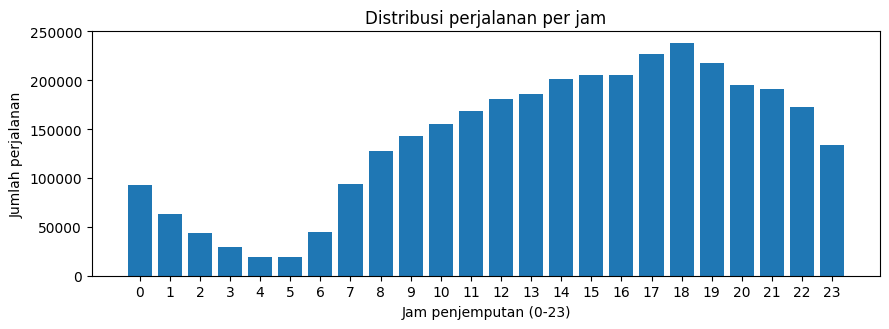

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()